Empirical Analysis of Price Elasticity Across Product Categories: A Data-Driven Microeconomic Study



The objective of this project is to analyze the relationship between price and quantity demanded across different categories of goods, and to examine how price elasticity varies between essential and nonessential products. The study aims to validate the law of demand using simulated data and to identify cases where consumer behavior deviates from standard economic theory

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as srs


In [3]:
df=pd.read_excel("elasticity2.xlsx")

In [4]:
df.head()

,Year,Month,Product,Category,Price,Quantity_Demanded,True_Elasticity_Setting,Demand_Type,Price_Change_%,Quantity_Change_%,Calculated_Elasticity
0,2010,1,Biscuits,FMCG,39.71,2326,-0.8,Inelastic,NaN,NaN,NaN
1,2010,2,Biscuits,FMCG,20.00,3768,-0.8,Inelastic,-49.63,61.99,-1.25
2,2010,3,Biscuits,FMCG,40.70,1913,-0.8,Inelastic,103.50,-49.23,-0.48
3,2010,4,Biscuits,FMCG,40.73,1579,-0.8,Inelastic,0.07,-17.46,-236.87
4,2010,5,Biscuits,FMCG,38.24,2147,-0.8,Inelastic,-6.11,35.97,-5.88


In [5]:
df.tail()

,Year,Month,Product,Category,Price,Quantity_Demanded,True_Elasticity_Setting,Demand_Type,Price_Change_%,Quantity_Change_%,Calculated_Elasticity
1915,2025,8,Toothpaste,FMCG,56.93,1019,-0.4,Inelastic,18.09,-3.32,-0.18
1916,2025,9,Toothpaste,FMCG,40.14,1060,-0.4,Inelastic,-29.49,4.02,-0.14
1917,2025,10,Toothpaste,FMCG,61.95,999,-0.4,Inelastic,54.33,-5.75,-0.11
1918,2025,11,Toothpaste,FMCG,36.27,1176,-0.4,Inelastic,-41.45,17.72,-0.43
1919,2025,12,Toothpaste,FMCG,30.22,1228,-0.4,Inelastic,-16.68,4.42,-0.27


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     1920 non-null   int64  
 1   Month                    1920 non-null   int64  
 2   Product                  1920 non-null   object 
 3   Category                 1920 non-null   object 
 4   Price                    1920 non-null   float64
 5   Quantity_Demanded        1920 non-null   int64  
 6   True_Elasticity_Setting  1920 non-null   float64
 7   Demand_Type              1920 non-null   object 
 8   Price_Change_%           1910 non-null   float64
 9   Quantity_Change_%        1910 non-null   float64
 10  Calculated_Elasticity    1910 non-null   float64
dtypes: float64(5), int64(3), object(3)
memory usage: 165.1+ KB


In [7]:
df.describe()

,Year,Month,Price,Quantity_Demanded,True_Elasticity_Setting,Price_Change_%,Quantity_Change_%,Calculated_Elasticity
count,1920.000000,1920.000000,1.920000e+03,1920.000000,1920.000000,1910.000000,1910.000000,1910.000000
mean,2017.500000,6.500000,5.126443e+05,608.497917,-0.390000,4.269424,6.111471,93.564796
std,4.610973,3.452952,1.512873e+06,709.417867,0.858652,31.135243,38.965436,4207.443785
min,2010.000000,1.000000,1.500000e+01,1.000000,-1.500000,-64.660000,-73.130000,-3768.870000
25%,2013.750000,3.750000,5.171750e+01,10.000000,-1.200000,-17.007500,-17.157500,-1.327500
50%,2017.500000,6.500000,2.659445e+03,297.000000,-0.550000,0.285000,0.000000,-0.420000
75%,2021.250000,9.250000,5.135488e+04,1040.250000,0.500000,20.412500,21.215000,0.630000
max,2025.000000,12.000000,8.078881e+06,4197.000000,1.100000,196.500000,306.060000,183834.520000


we have to check if the data contain any missing values or not by executing the code using isnull().sum()

In [8]:
df.isnull().sum()

Year                        0
Month                       0
Product                     0
Category                    0
Price                       0
Quantity_Demanded           0
True_Elasticity_Setting     0
Demand_Type                 0
Price_Change_%             10
Quantity_Change_%          10
Calculated_Elasticity      10
dtype: int64

The important thing to look here is that there is 0 null values for the columns "price" and "Quantity_Demanded", 
other than that the data for "Price_Change","Quantity_Change" contain 10 null values for each, so we can execute the dropna(inplace=True) command to remove it as it wont make any clear difference in the objective and make the data look more clean.

In [58]:
df.dropna()



,Year,Month,Product,Category,Price,Quantity_Demanded,True_Elasticity_Setting,Demand_Type,Price_Change_%,Quantity_Change_%,Calculated_Elasticity,Abs_Elasticity,Price_Direction,Demand_Direction
1,2010,2,Biscuits,FMCG,20.00,3768,-0.8,Inelastic,-49.63,61.99,-1.25,1.25,Decrease,Increase
2,2010,3,Biscuits,FMCG,40.70,1913,-0.8,Inelastic,103.50,-49.23,-0.48,0.48,Increase,Decrease
4,2010,5,Biscuits,FMCG,38.24,2147,-0.8,Inelastic,-6.11,35.97,-5.88,5.88,Decrease,Increase
5,2010,6,Biscuits,FMCG,51.82,1541,-0.8,Inelastic,35.51,-28.23,-0.79,0.79,Increase,Decrease
6,2010,7,Biscuits,FMCG,33.53,2187,-0.8,Inelastic,-35.30,41.92,-1.19,1.19,Decrease,Increase
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915,2025,8,Toothpaste,FMCG,56.93,1019,-0.4,Inelastic,18.09,-3.32,-0.18,0.18,Increase,Decrease
1916,2025,9,Toothpaste,FMCG,40.14,1060,-0.4,Inelastic,-29.49,4.02,-0.14,0.14,Decrease,Increase
1917,2025,10,Toothpaste,FMCG,61.95,999,-0.4,Inelastic,54.33,-5.75,-0.11,0.11,Increase,Decrease
1918,2025,11,Toothpaste,FMCG,36.27,1176,-0.4,Inelastic,-41.45,17.72,-0.43,0.43,Decrease,Increase


In [57]:
df.loc[:, "Abs_Elasticity"] = df["Calculated_Elasticity"].abs()

#The above command will add a new column-["Abs_Elasticity] which basically will contain all the Calculated_Elasticity 
#values but with positive or absolute values as we only need absolute Values for our Objective to satisfy.


In [18]:
df.head()

,Year,Month,Product,Category,Price,Quantity_Demanded,True_Elasticity_Setting,Demand_Type,Price_Change_%,Quantity_Change_%,Calculated_Elasticity,Abs_Elasticity
1,2010,2,Biscuits,FMCG,20.00,3768,-0.8,Inelastic,-49.63,61.99,-1.25,1.25
2,2010,3,Biscuits,FMCG,40.70,1913,-0.8,Inelastic,103.50,-49.23,-0.48,0.48
3,2010,4,Biscuits,FMCG,40.73,1579,-0.8,Inelastic,0.07,-17.46,-236.87,236.87
4,2010,5,Biscuits,FMCG,38.24,2147,-0.8,Inelastic,-6.11,35.97,-5.88,5.88
5,2010,6,Biscuits,FMCG,51.82,1541,-0.8,Inelastic,35.51,-28.23,-0.79,0.79


In [20]:
df["Price_Direction"] = np.where(df["Price_Change_%"] > 0, "Increase", "Decrease")
#The Above Command will Create a column Named-["Price_Direction] indicating Increase or Decrease for 
#values Greater than 0 and for less than 0 respectively. (essential to get the direction)

In [21]:
df.head()

,Year,Month,Product,Category,Price,Quantity_Demanded,True_Elasticity_Setting,Demand_Type,Price_Change_%,Quantity_Change_%,Calculated_Elasticity,Abs_Elasticity,Price_Direction
1,2010,2,Biscuits,FMCG,20.00,3768,-0.8,Inelastic,-49.63,61.99,-1.25,1.25,Decrease
2,2010,3,Biscuits,FMCG,40.70,1913,-0.8,Inelastic,103.50,-49.23,-0.48,0.48,Increase
3,2010,4,Biscuits,FMCG,40.73,1579,-0.8,Inelastic,0.07,-17.46,-236.87,236.87,Increase
4,2010,5,Biscuits,FMCG,38.24,2147,-0.8,Inelastic,-6.11,35.97,-5.88,5.88,Decrease
5,2010,6,Biscuits,FMCG,51.82,1541,-0.8,Inelastic,35.51,-28.23,-0.79,0.79,Increase


Now we will apply the same logic for Demand as well,
by applying the code below

In [22]:
df["Demand_Direction"] = np.where(df["Quantity_Change_%"] > 0, "Increase", "Decrease")

In [23]:
df.head()

,Year,Month,Product,Category,Price,Quantity_Demanded,True_Elasticity_Setting,Demand_Type,Price_Change_%,Quantity_Change_%,Calculated_Elasticity,Abs_Elasticity,Price_Direction,Demand_Direction
1,2010,2,Biscuits,FMCG,20.00,3768,-0.8,Inelastic,-49.63,61.99,-1.25,1.25,Decrease,Increase
2,2010,3,Biscuits,FMCG,40.70,1913,-0.8,Inelastic,103.50,-49.23,-0.48,0.48,Increase,Decrease
3,2010,4,Biscuits,FMCG,40.73,1579,-0.8,Inelastic,0.07,-17.46,-236.87,236.87,Increase,Decrease
4,2010,5,Biscuits,FMCG,38.24,2147,-0.8,Inelastic,-6.11,35.97,-5.88,5.88,Decrease,Increase
5,2010,6,Biscuits,FMCG,51.82,1541,-0.8,Inelastic,35.51,-28.23,-0.79,0.79,Increase,Decrease


Now to check the Law of Demand for the Data which we are working on, we need to construct a table for both Price and Quantity to analysis the Behaviour of each other for a Quantity change corresponding to 
the Price Change..

In [24]:
pd.crosstab(df["Price_Direction"], df["Demand_Direction"])

Demand_Direction,Decrease,Increase
Price_Direction,,
Decrease,383,561
Increase,660,306


The Table Shows a Mixed Variety of Results, as Majority of Goods allign obeying the Law of Demand
some goods aren't.
The Goods which are Not following The Law of Demand are Giffin Goods or veblen Goods.

In [29]:
df[(df["Price_Direction"] == "Increase") & (df["Demand_Direction"] == "Increase")]


,Year,Month,Product,Category,Price,Quantity_Demanded,True_Elasticity_Setting,Demand_Type,Price_Change_%,Quantity_Change_%,Calculated_Elasticity,Abs_Elasticity,Price_Direction,Demand_Direction
12,2011,1,Biscuits,FMCG,46.60,1913,-0.8,Inelastic,26.42,4.99,0.19,0.19,Increase,Increase
22,2011,11,Biscuits,FMCG,40.61,1842,-0.8,Inelastic,1.78,0.99,0.55,0.55,Increase,Increase
24,2012,1,Biscuits,FMCG,49.34,1733,-0.8,Inelastic,3.22,1.46,0.45,0.45,Increase,Increase
32,2012,9,Biscuits,FMCG,25.03,2807,-0.8,Inelastic,5.61,2.67,0.48,0.48,Increase,Increase
56,2014,9,Biscuits,FMCG,51.81,1850,-0.8,Inelastic,14.57,21.15,1.45,1.45,Increase,Increase
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1873,2022,2,Toothpaste,FMCG,43.93,1101,-0.4,Inelastic,59.05,10.21,0.17,0.17,Increase,Increase
1878,2022,7,Toothpaste,FMCG,57.68,964,-0.4,Inelastic,12.20,23.91,1.96,1.96,Increase,Increase
1898,2024,3,Toothpaste,FMCG,42.91,1270,-0.4,Inelastic,33.84,23.06,0.68,0.68,Increase,Increase
1902,2024,7,Toothpaste,FMCG,64.51,1066,-0.4,Inelastic,31.04,20.45,0.66,0.66,Increase,Increase


The Goods shows Above can be-
prestige Goods(Luxuary)
Data discrepancy(Noise)

In [30]:
df.groupby("Category")["Abs_Elasticity"].agg(["mean", "std", "min", "max"])

,mean,std,min,max
Category,,,,
FMCG,9.187474,139.122228,0.0,3768.87
Luxury_Goods,324.126510,7679.694848,0.0,183834.52
Normal_Goods,4.322408,33.944672,0.0,795.19


The Catagory segregation is most important thing for interpretation
FMCG - low mean elasticity - necessity
Luxury -high mean - discretionary
Normal - around 1



In [32]:
df = df[df["Abs_Elasticity"] < 10]
#We need to execute this command as massive outliers were present in the data which were affecting the 
#data presentation and due to this it was necessary to restrict the["Abs_Elasticity"] under 10(can be other than 10 too)

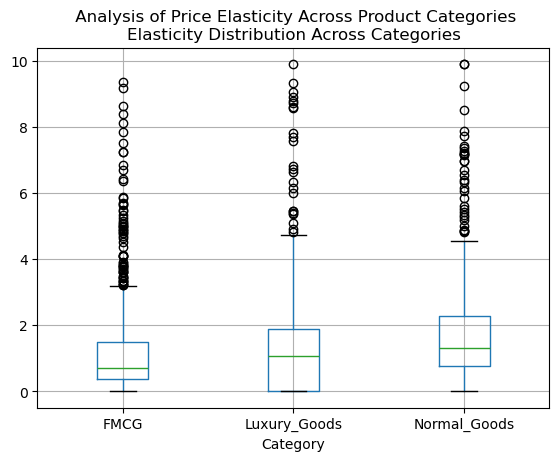

In [33]:
df.boxplot(column="Abs_Elasticity", by="Category")
plt.title("Elasticity Distribution Across Categories")
plt.suptitle(" Analysis of Price Elasticity Across Product Categories")
plt.show()

The Dots in the Box plot which is above 4-6 are majorly outliers as no Data is perfect enough to state the 
Objective (LOD)
The analysis which we can make from the Box Plot is that the FMCG goods contain a smaller,contracted Box which is 
indicating the Mean to be low.
The Luxuary Goods Catagory is having a box more wide and bigger than the FMCG one and tells us the story of
mean to be high compared to FMCG.
 for Normal_Goods  as the Plot shows mixed fluctuation and majorly moderate to be considered.(Acceptable)


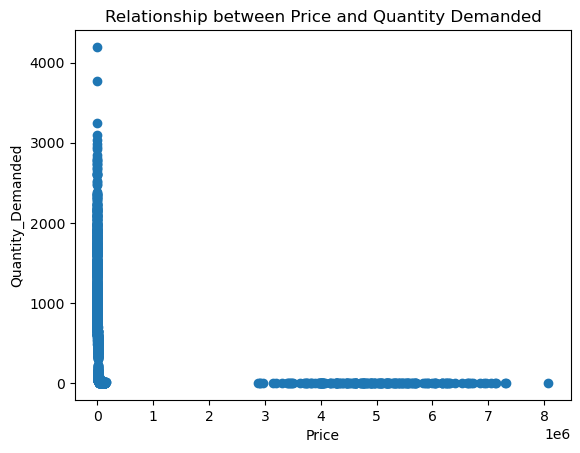

In [35]:
plt.scatter(df["Price"],df["Quantity_Demanded"])
plt.xlabel("Price")
plt.ylabel("Quantity_Demanded")
plt.title("Relationship between Price and Quantity Demanded")
plt.show()

The Scatter plot above seems unusual and incorrect but the code isnt the falt, its the data which is 
highly affected by outliers
we need to correct this by applying log or by restricting the data


In [42]:
dfnew = df[(df["Price"] < df["Price"].quantile(0.99)) &
    (df["Quantity_Demanded"] < df["Quantity_Demanded"].quantile(0.99))]

the above code is the way to make the data more clean and understandable over the scatterplot as
it will remove the above 1% data that contains the high outliers, ir by adding log to the given code
this will make the data more cleaner and understandable, the code which i used above is just for the data 
rectification.

In [45]:
df["Price"].describe()

count    1.837000e+03
mean     5.202061e+05
std      1.526012e+06
min      1.500000e+01
25%      5.141000e+01
50%      1.271860e+03
75%      5.191099e+04
max      8.078881e+06
Name: Price, dtype: float64

as we can see that the data here is still holding maximum value in a huge number

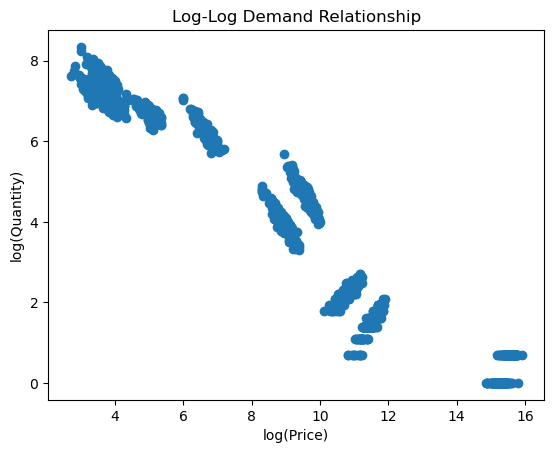

In [46]:
plt.scatter(np.log(df["Price"]), np.log(df["Quantity_Demanded"]))

plt.xlabel("log(Price)")
plt.ylabel("log(Quantity)")
plt.title("Log-Log Demand Relationship")

plt.show()

log(Q)=Blog(P) here the term B is the slope which is Downward sloping as we can see in the Scatter plot
above,
The clusters here are basically for different catagories ( FMCG,Luxuary and all)
the relationship also revolves around the elasticity and slope. as the slope does represents the Elasticity


The log-log scatter plot reveals a clear inverse relationship between price and quantity demanded, consistent with the law of demand. The presence of distinct clusters suggests heterogeneity across product categories, with low-priced goods exhibiting higher demand and high-priced goods showing lower demand. The log-log specification also allows elasticity to be interpreted directly from the slope of the relationship

FMCG -> mostly inelastic
Luxury -> mostly elastic


CONCLUSION

The analysis confirms the existence of an inverse relationship between price and quantity demanded for the majority of observations, supporting the law of demand. This is visible both in the cleaned scatter plots and through the negative correlation between price and quantity.

Category-wise analysis shows clear differences in consumer responsiveness. FMCG goods exhibit relatively low elasticity, indicating that demand remains stable despite price changes, which is consistent with their essential nature. In contrast, luxury and higher-priced goods show greater elasticity, suggesting that consumers are more sensitive to price variations in discretionary purchases.

The distribution of elasticity further highlights that essential goods tend to have more concentrated and lower values, while non-essential goods display wider variation. This reflects differences in consumer preferences, availability of substitutes, and necessity.

A small number of observations were found to move in the same direction as price changes, indicating atypical behavior. These cases may represent prestige-driven consumption or anomalies in the data, and they highlight that real-world demand does not always strictly follow theoretical expectations.

Overall, the project demonstrates that while the law of demand broadly holds, elasticity varies significantly across product types, and understanding this variation is important for pricing decisions and market analysis